In [2]:
import json
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

# GLOBAL CONSTANTS
PATH_TO_FIGURES = "./fig/"
JSON_PATH = "./empirical_data_by_count_completed.json"
FIGSIZE = (9, 6)
LEGEND_FONTSIZE = 18
LABEL_FONTSIZE = 28
line_width = 3.5
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
system = ["GAE", "vSoC", "Anbox", "Redroid", "MCon"]
font = {'family': 'Arial',
        'weight': 'normal',
        'size': LABEL_FONTSIZE}

# envsetup
plt.rc('font', **font)
plt.rcParams.update({'legend.handlelength': 1.3, 'legend.borderpad': 0.25,
                     "legend.labelspacing": 0.25, "legend.handletextpad": 0.5})
plt.rcParams['hatch.linewidth'] = line_width
pd.set_option("display.max_colwidth", 5000)
pd.set_option("display.max_columns", 10000)
pd.set_option("display.max_rows", 100)
os.makedirs(PATH_TO_FIGURES, exist_ok=True)
warnings.filterwarnings('ignore')

# refresh the fonts just installed
matplotlib.font_manager._load_fontmanager(try_read_cache=False)

In [3]:
# Hardcoded final plotting data (no file read, no post-processing)
gae = [13.22, 13.29, 13.061999999999998, 14.534749999999999, 23.263933333333338]
vsoc = [24.111, 19.1025, 16.8365, 16.657874999999997, 18.1609375, 27.06925]
anbox = [58.0, 58.738, 73.19692245617058, 107.14102004058344, 187.05063300877654, 410.3724462856462, 1092.652685782711]
redroid = [15.998, 16.810000000000002, 20.62975, 44.134625, 34.97625, 118.15257291666666, 204.8071875]
mcon = [1.034, 1.599, 2.9217500000000003, 6.056750000000001, 11.8626875, 28.0700625, 65.14839062499999, 171.12, 189.28]
gae_max = 16
vsoc_max = 20
anbox_max = 62
redroid_max = 64
mcon_max = 137
x_ticks = np.array([1, 2, 4, 8, 16, 32, 64, 128])
x_log = np.log2(x_ticks)
def align_to_log_axis(y, max_x):
    n = len(y)
    log_end = np.log2(max_x)
    x = np.linspace(0, n - 2, n - 1) if n > 1 else np.array([])
    x = np.append(x, log_end)
    return x, y
x_gae, y_gae = align_to_log_axis(gae, gae_max)
x_vsoc, y_vsoc = align_to_log_axis(vsoc, vsoc_max)
x_anbox, y_anbox = align_to_log_axis(anbox, anbox_max)
x_redroid, y_redroid = align_to_log_axis(redroid, redroid_max)
x_mcon, y_mcon = align_to_log_axis(mcon, mcon_max)

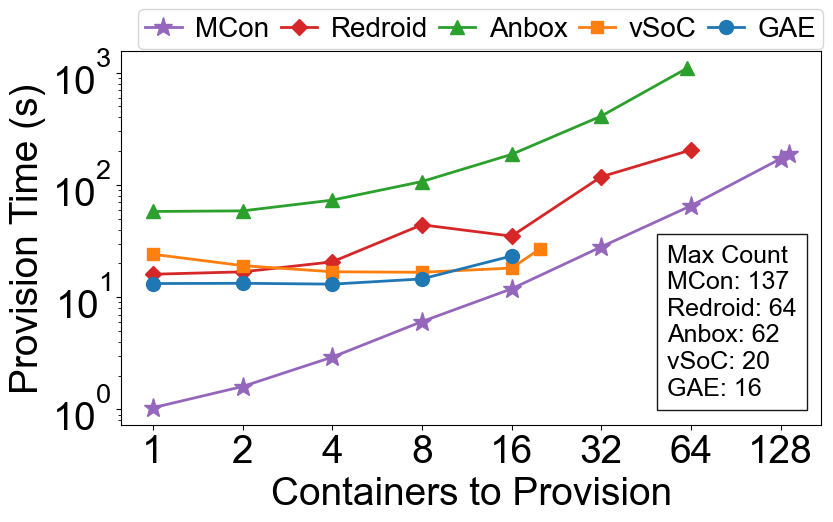

In [4]:
# =========================
# 画图（样式与原 notebook 保持一致）
# =========================
plt.figure(figsize=FIGSIZE)

plt.plot(x_mcon, y_mcon, marker="*", markersize=14, linewidth=2, label="MCon", color=colors[4])
plt.plot(x_redroid, y_redroid, marker="D", markersize=8, linewidth=2, label="Redroid", color=colors[3])
plt.plot(x_anbox, y_anbox, marker="^", markersize=10, linewidth=2, label="Anbox", color=colors[2])
plt.plot(x_vsoc, y_vsoc, marker="s", markersize=8, linewidth=2, label="vSoC", color=colors[1])
plt.plot(x_gae, y_gae, marker="o", markersize=10, linewidth=2, label="GAE", color=colors[0])

plt.xticks(x_log, x_ticks, fontsize=LABEL_FONTSIZE)
plt.xlabel("Containers to Provision", fontsize=LABEL_FONTSIZE)
plt.ylabel("Provision Time (s)", fontsize=LABEL_FONTSIZE)
plt.yscale("log", base=10)

proxy_i_text = (
    f"Max Count\n"
    f"MCon: {mcon_max}\n"
    f"Redroid: {redroid_max}\n"
    f"Anbox: {anbox_max}\n"
    f"vSoC: {vsoc_max}\n"
    f"GAE: {gae_max}"
)

plt.annotate(
    proxy_i_text,
    xy=(0.8, 0.82),
    xytext=(0.78, 0.08),
    textcoords="axes fraction",
    bbox=dict(boxstyle="square,pad=0.4", fc="white", ec="black", alpha=0.9),
    fontsize=LEGEND_FONTSIZE,
    color="black"
)

plt.legend(
    loc="upper left",
    ncol=5,
    bbox_to_anchor=(0.005, 1.15),
    fontsize=20,
    columnspacing=0.4,
)

plt.tight_layout()
plt.savefig(PATH_TO_FIGURES + "container_boot_time.pdf", format="pdf", bbox_inches="tight", pad_inches=0)
plt.show()